# Challenge: TelecomX # 1

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

## Extracción de datos

In [2]:
datos = pd.read_json('https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json')
datos.sample(15)

,customerID,Churn,customer,phone,internet,account
4528,6204-IEUXJ,Yes,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2741,3795-CAWEX,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Two year', 'PaperlessBilling': '..."
6318,8695-ARGXZ,No,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
826,1171-TYKUR,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'No', 'OnlineSecurity': 'N...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2159,3018-TFTSU,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3910,5346-BZCHP,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'No', 'OnlineSecurity': 'N...","{'Contract': 'Two year', 'PaperlessBilling': '..."
5446,7459-RRWQZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
5565,7609-YBPXG,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."
2810,3896-RCYYE,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'No', 'MultipleLines': 'No ph...","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7002,9640-HXEAM,,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'No', 'MultipleLines': 'No ph...","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


## Transformación

### Conocer el conjunto de datos

In [3]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [4]:
for i,j in enumerate(['customer', 'phone', 'internet', 'account']):
    print(f'\nInfo en la columna {i+3}: {list(datos[j][0])}')
    print('=================================\n')



Info en la columna 3: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure']


Info en la columna 4: ['PhoneService', 'MultipleLines']


Info en la columna 5: ['InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']


Info en la columna 6: ['Contract', 'PaperlessBilling', 'PaymentMethod', 'Charges']



### Comprobación de incoherencias en los datos y manejo de las mismas

In [5]:
# existen valores faltantes, pues la columna se refiere a 
# la permanencia o no de un cliente, de manera que solo puede
# haber dos posibilidades.
pd.unique(datos['Churn'])

array(['No', 'Yes', ''], dtype=object)

In [6]:
# expandir columnas con diccionarios
datos_ex = pd.concat([
    datos[['customerID','Churn']],
    pd.json_normalize(datos['customer']),
    pd.json_normalize(datos['phone']),
    pd.json_normalize(datos['internet']),
    pd.json_normalize(datos['account'])
], axis=1)
datos_ex.sample(10)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
4682,6413-XKKPU,Yes,Male,0,Yes,Yes,17,Yes,No,Fiber optic,Yes,No,Yes,No,Yes,No,Month-to-month,Yes,Electronic check,89.40,1539.45
2360,3295-YVUSR,No,Male,1,No,No,2,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,72.60,154.3
742,1062-LHZOD,Yes,Male,0,Yes,Yes,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,69.90,69.9
5968,8158-WPEZG,No,Male,0,No,No,11,No,No phone service,DSL,No,Yes,No,Yes,No,No,Month-to-month,Yes,Electronic check,35.65,425.1
1183,1689-YQBYY,No,Female,0,No,Yes,12,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,76.60,893
901,1266-NZYUI,No,Female,0,Yes,Yes,72,Yes,Yes,DSL,Yes,No,Yes,Yes,No,No,Two year,No,Bank transfer (automatic),66.85,4758.8
6689,9208-OLGAQ,No,Female,1,No,No,18,Yes,No,Fiber optic,No,No,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,84.95,1443.65
2354,3280-NMUVX,No,Male,0,Yes,Yes,34,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Credit card (automatic),19.60,678.8
1001,1402-PTHGN,No,Female,0,Yes,Yes,18,Yes,No,DSL,Yes,Yes,No,Yes,No,No,One year,Yes,Mailed check,61.50,1087.45
4322,5937-EORGB,No,Male,1,Yes,No,15,Yes,Yes,Fiber optic,Yes,No,Yes,No,Yes,No,Month-to-month,Yes,Electronic check,96.50,1392.25


In [7]:
datos_ex.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [8]:
l1 = len(pd.unique(datos_ex['customerID']))

print(f'La lingitud de los datos únicos en el data frame es: {l1}')
print(f'La cantidad de filas en el data frame es: {len(datos_ex)}')
if l1 == len(datos_ex):
    print('No hay datos duplicados en el data frame')


La lingitud de los datos únicos en el data frame es: 7267
La cantidad de filas en el data frame es: 7267
No hay datos duplicados en el data frame


In [9]:
for col in datos_ex.select_dtypes(include='object'):
    print(f"\nColumna: {col}")
    print(datos_ex[col].unique())


Columna: customerID
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']

Columna: Churn
['No' 'Yes' '']

Columna: gender
['Female' 'Male']

Columna: Partner
['Yes' 'No']

Columna: Dependents
['Yes' 'No']

Columna: PhoneService
['Yes' 'No']

Columna: MultipleLines
['No' 'Yes' 'No phone service']

Columna: InternetService
['DSL' 'Fiber optic' 'No']

Columna: OnlineSecurity
['No' 'Yes' 'No internet service']

Columna: OnlineBackup
['Yes' 'No' 'No internet service']

Columna: DeviceProtection
['No' 'Yes' 'No internet service']

Columna: TechSupport
['Yes' 'No' 'No internet service']

Columna: StreamingTV
['Yes' 'No' 'No internet service']

Columna: StreamingMovies
['No' 'Yes' 'No internet service']

Columna: Contract
['One year' 'Month-to-month' 'Two year']

Columna: PaperlessBilling
['Yes' 'No']

Columna: PaymentMethod
['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']

Columna: Charges.Total
['593.3' '542.4' '280.8

In [10]:
datos_ex['Charges.Total'] = pd.to_numeric(datos_ex['Charges.Total'], errors='coerce')

In [11]:
datos_ex.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [12]:
df_clean = datos_ex[datos_ex.Churn != '']
df_clean.dropna(inplace=True)
#df_clean[df_clean[Charges.Total].isna()]

/var/folders/x5/6dss2r_s03z66shv12gx13dm0000gn/T/ipykernel_62816/1964041165.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean.dropna(inplace=True)


Se corrigió el tipo de datos de `Charges.Total` a valores numéricos, borrando a la vez los que tengan este dato inexistente. Se suprimieron además las filas en las cuales la característica `Churn` estaba vacía.

### Columna de cuentas diarias

In [13]:
df_clean['Cuentas_Diarias'] = df_clean['Charges.Monthly']/30
df_clean.sample(10)

/var/folders/x5/6dss2r_s03z66shv12gx13dm0000gn/T/ipykernel_62816/4205414002.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Cuentas_Diarias'] = df_clean['Charges.Monthly']/30


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
2444,3411-WLRSQ,No,Female,1,Yes,No,3,Yes,No,Fiber optic,No,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),74.60,239.05,2.486667
910,1282-IHQAC,No,Male,1,No,No,70,No,No phone service,DSL,No,Yes,Yes,No,Yes,No,One year,Yes,Credit card (automatic),44.05,3011.65,1.468333
6614,9093-FPDLG,No,Female,0,No,No,11,Yes,No,Fiber optic,No,Yes,Yes,Yes,No,Yes,Month-to-month,Yes,Electronic check,94.20,999.90,3.140000
4102,5624-BQSSA,Yes,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.95,20.95,0.698333
5329,7277-KAMWT,No,Male,0,No,No,13,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),20.00,268.45,0.666667
1665,2362-IBOOY,Yes,Male,0,No,No,36,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,84.75,3050.15,2.825000
364,0523-VNGTF,No,Female,1,No,No,52,No,No phone service,DSL,No,Yes,Yes,Yes,Yes,No,Month-to-month,Yes,Electronic check,50.50,2566.30,1.683333
2326,3244-CQPHU,No,Female,1,No,No,72,Yes,Yes,Fiber optic,Yes,Yes,No,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),110.10,7746.70,3.670000
2348,3274-NSDWE,No,Female,0,No,No,68,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),19.60,1441.65,0.653333
164,0260-ZDLGK,Yes,Female,0,No,Yes,9,Yes,No,DSL,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Mailed check,72.90,651.40,2.430000


### Estandarización y transformación de datos

In [14]:
# primero verifico cuales cambiar
for col in df_clean.select_dtypes(include='object'):
    print(f"\nColumna: {col}")
    print(df_clean[col].unique())


Columna: customerID
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']

Columna: Churn
['No' 'Yes']

Columna: gender
['Female' 'Male']

Columna: Partner
['Yes' 'No']

Columna: Dependents
['Yes' 'No']

Columna: PhoneService
['Yes' 'No']

Columna: MultipleLines
['No' 'Yes' 'No phone service']

Columna: InternetService
['DSL' 'Fiber optic' 'No']

Columna: OnlineSecurity
['No' 'Yes' 'No internet service']

Columna: OnlineBackup
['Yes' 'No' 'No internet service']

Columna: DeviceProtection
['No' 'Yes' 'No internet service']

Columna: TechSupport
['Yes' 'No' 'No internet service']

Columna: StreamingTV
['Yes' 'No' 'No internet service']

Columna: StreamingMovies
['No' 'Yes' 'No internet service']

Columna: Contract
['One year' 'Month-to-month' 'Two year']

Columna: PaperlessBilling
['Yes' 'No']

Columna: PaymentMethod
['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']


In [15]:
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})
df_clean['gender'] = df_clean['gender'].map({'Male': 1, 'Female': 0})
df_clean['Partner'] = df_clean['Partner'].map({'Yes': 1, 'No': 0})
df_clean['Dependents'] = df_clean['Dependents'].map({'Yes': 1, 'No': 0})
df_clean['PhoneService'] = df_clean['PhoneService'].map({'Yes': 1, 'No': 0})
df_clean['MultipleLines'] = df_clean['MultipleLines'].replace('No phone service', 'No')
df_clean['MultipleLines'] = df_clean['MultipleLines'].map({'Yes': 1, 'No': 0})
df_clean['OnlineSecurity'] = df_clean['OnlineSecurity'].replace('No internet service', 'No')
df_clean['OnlineSecurity'] = df_clean['OnlineSecurity'].map({'Yes': 1, 'No': 0})
df_clean['OnlineBackup'] = df_clean['OnlineBackup'].replace('No internet service', 'No')
df_clean['OnlineBackup'] = df_clean['OnlineBackup'].map({'Yes': 1, 'No': 0})
df_clean['DeviceProtection'] = df_clean['DeviceProtection'].replace('No internet service', 'No')
df_clean['DeviceProtection'] = df_clean['DeviceProtection'].map({'Yes': 1, 'No': 0})
df_clean['TechSupport'] = df_clean['TechSupport'].replace('No internet service', 'No')
df_clean['TechSupport'] = df_clean['TechSupport'].map({'Yes': 1, 'No': 0})
df_clean['StreamingTV'] = df_clean['StreamingTV'].replace('No internet service', 'No')
df_clean['StreamingTV'] = df_clean['StreamingTV'].map({'Yes': 1, 'No': 0})
df_clean['StreamingMovies'] = df_clean['StreamingMovies'].replace('No internet service', 'No')
df_clean['StreamingMovies'] = df_clean['StreamingMovies'].map({'Yes': 1, 'No': 0})
df_clean['Contract'] = df_clean['Contract'].map({'Month-to-month': 0, 'One year': 1, 'Two year': 2})
df_clean['PaperlessBilling'] = df_clean['PaperlessBilling'].map({'Yes': 1, 'No': 0})

/var/folders/x5/6dss2r_s03z66shv12gx13dm0000gn/T/ipykernel_62816/673616404.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})
/var/folders/x5/6dss2r_s03z66shv12gx13dm0000gn/T/ipykernel_62816/673616404.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['gender'] = df_clean['gender'].map({'Male': 1, 'Female': 0})
/var/folders/x5/6dss2r_s03z66shv12gx13dm0000gn/T/ipykernel_62816/673616404.py:3: SettingWithCopyWarning: 
A value is trying t

In [16]:
df_clean.sample(10)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
2676,3719-TDVQB,0,0,1,1,0,54,1,0,No,0,0,0,0,0,0,2,1,Mailed check,18.95,1031.10,0.631667
5660,7730-CLDSV,0,0,0,1,1,72,1,1,Fiber optic,0,1,1,1,0,1,2,1,Bank transfer (automatic),98.65,7129.45,3.288333
2365,3307-TLCUD,0,1,0,1,0,17,0,0,DSL,1,0,1,0,0,0,0,0,Mailed check,34.40,592.75,1.146667
82,0129-QMPDR,0,1,0,1,1,44,1,0,No,0,0,0,0,0,0,1,1,Bank transfer (automatic),20.50,865.05,0.683333
4910,6712-OAWRH,1,0,1,0,0,26,1,0,Fiber optic,0,0,0,0,1,1,0,1,Electronic check,91.25,2351.80,3.041667
4358,5981-ITEMU,1,1,0,1,0,40,1,1,Fiber optic,0,0,0,0,1,1,0,1,Bank transfer (automatic),97.10,3706.95,3.236667
3259,4547-LYTDD,1,0,0,0,0,16,1,1,Fiber optic,0,0,0,0,0,0,0,0,Electronic check,72.65,1194.30,2.421667
1768,2514-GINMM,1,1,0,0,0,1,1,0,Fiber optic,0,0,0,0,1,0,0,1,Electronic check,79.50,79.50,2.650000
1880,2672-DZUOY,1,1,0,0,0,1,0,0,DSL,0,0,0,0,0,0,0,1,Electronic check,25.15,25.15,0.838333
5965,8152-UOBNY,0,0,1,0,0,50,1,1,Fiber optic,0,1,0,1,1,1,1,1,Electronic check,106.80,5347.95,3.560000


## Carga y Análisis

### Análisis Descriptivo

In [17]:
df_clean.describe()

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,Charges.Monthly,Charges.Total,Cuentas_Diarias
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.265785,0.504693,0.162400,0.482509,0.298493,32.421786,0.903299,0.421928,0.286547,0.344852,0.343857,0.290102,0.384386,0.388367,0.688567,0.592719,64.798208,2283.300441,2.159940
std,0.441782,0.500014,0.368844,0.499729,0.457629,24.545260,0.295571,0.493902,0.452180,0.475354,0.475028,0.453842,0.486484,0.487414,0.832934,0.491363,30.085974,2266.771362,1.002866
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.608333
25%,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.587500,401.450000,1.186250
50%,0.000000,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.350000,1397.475000,2.345000
75%,1.000000,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.862500,3794.737500,2.995417
max,1.000000,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,118.750000,8684.800000,3.958333


### Distribución de Evasión

/var/folders/x5/6dss2r_s03z66shv12gx13dm0000gn/T/ipykernel_62816/379776827.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No', 'Sí'])


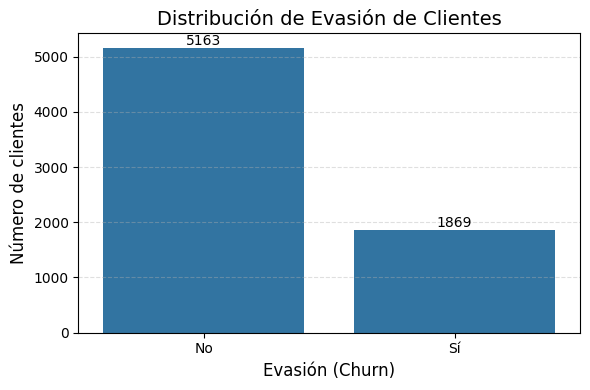

In [27]:
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df_clean, x='Churn')

plt.title('Distribución de Evasión de Clientes', fontsize=14)
plt.xlabel('Evasión (Churn)', fontsize=12)
plt.ylabel('Número de clientes', fontsize=12)

ax.set_xticklabels(['No', 'Sí'])

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### Recuento de evasión por variables categóricas

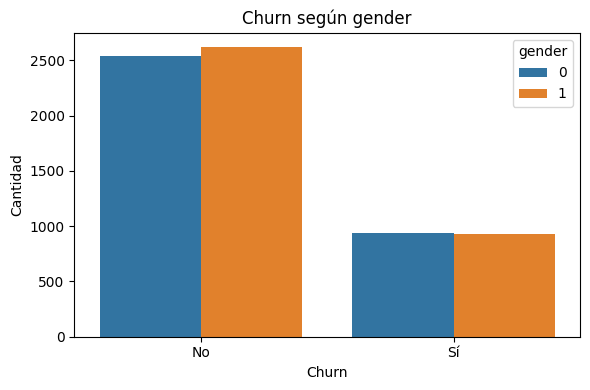

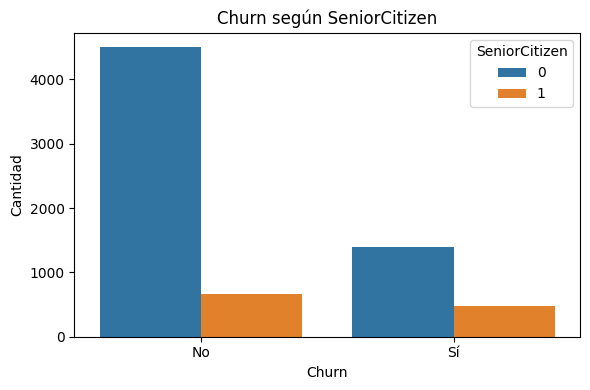

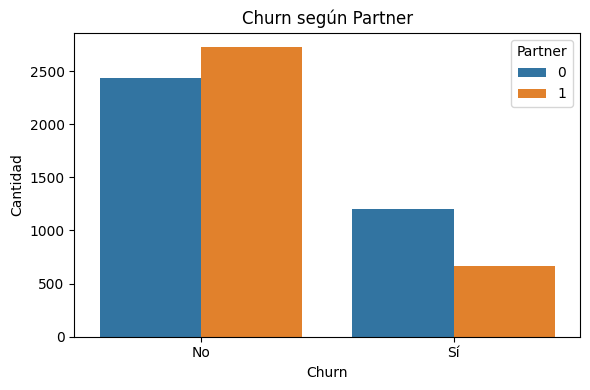

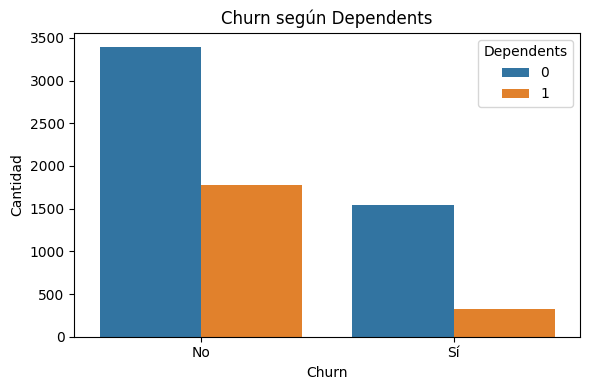

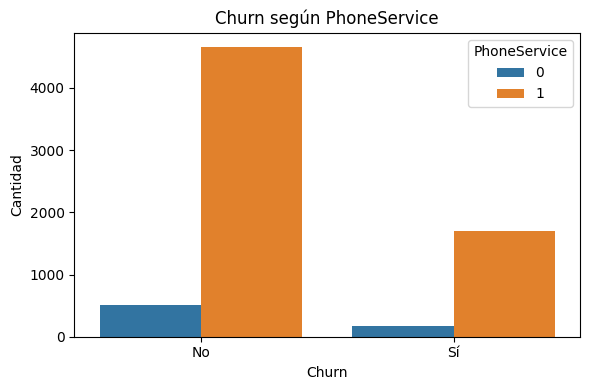

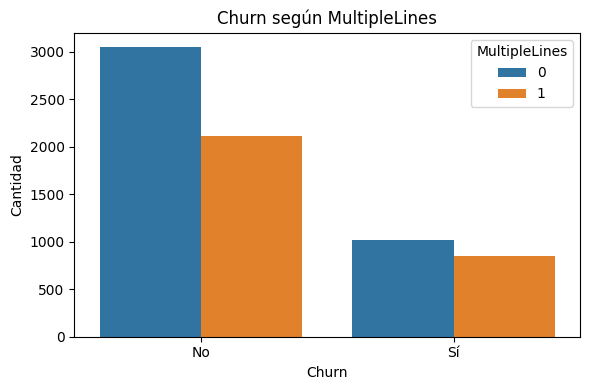

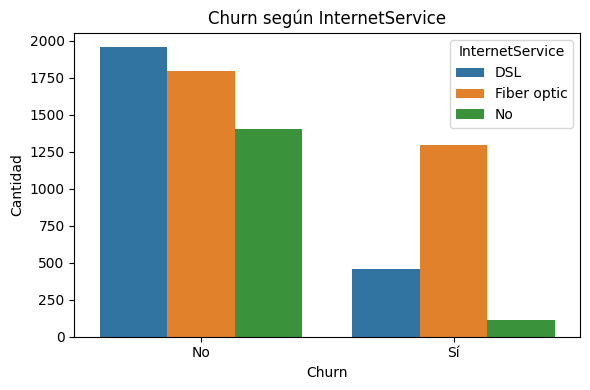

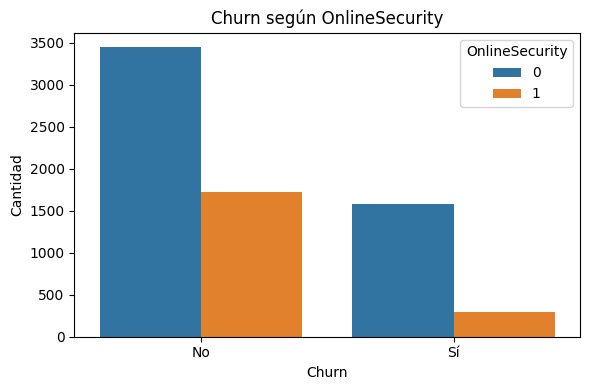

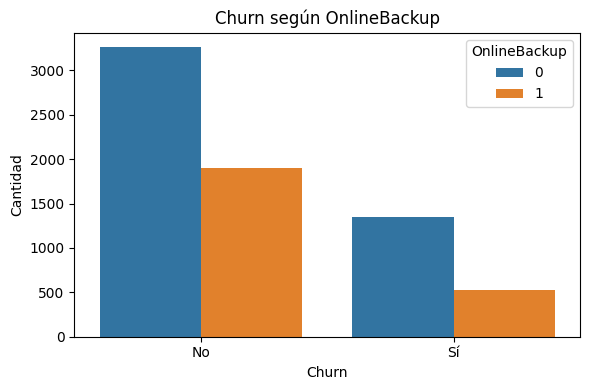

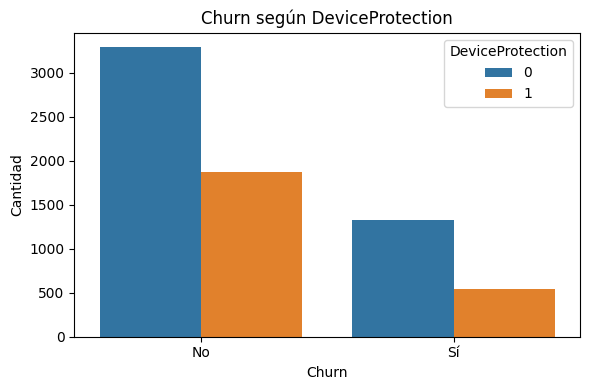

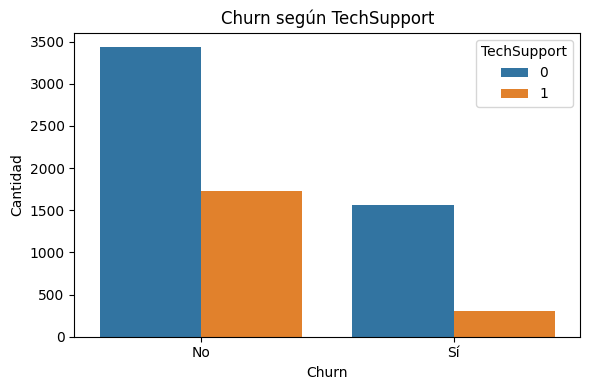

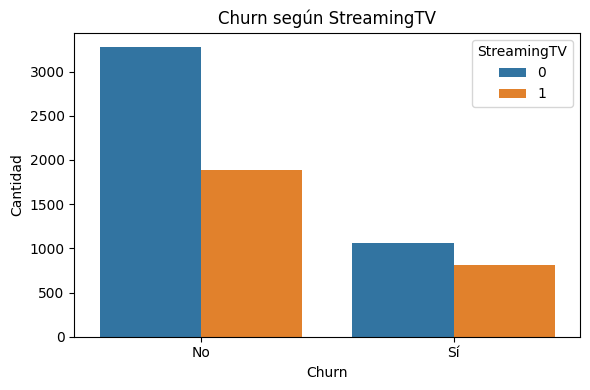

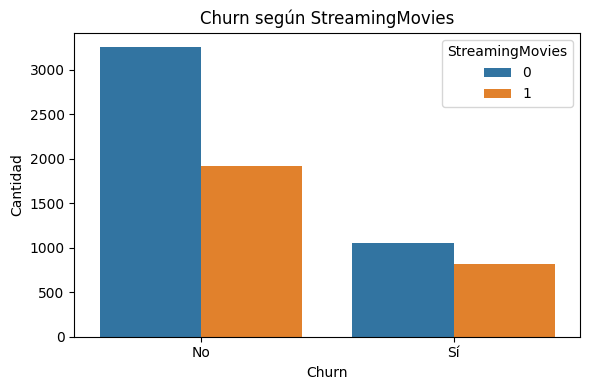

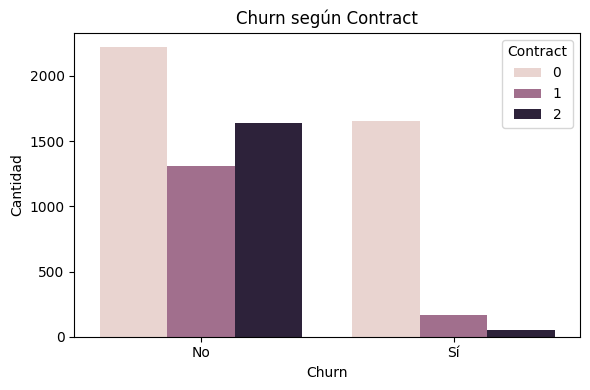

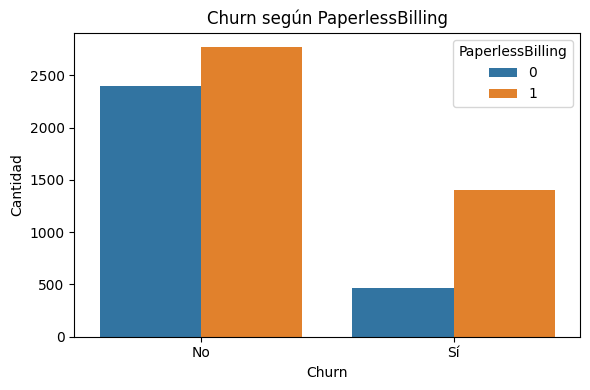

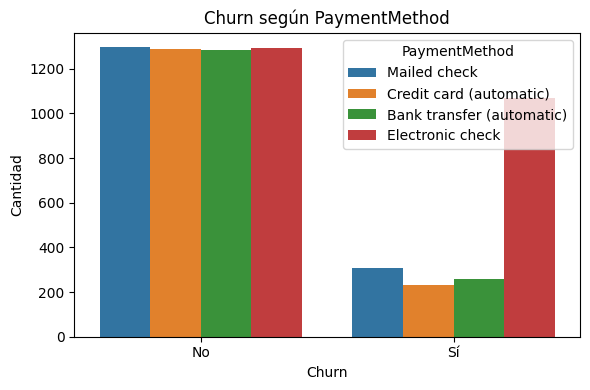

In [ ]:
# columnas a usar como hue
hue_columns = ['gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod']

for col in hue_columns:
    
    plt.figure(figsize=(6,4))
    
    sns.countplot(
        data=df_clean,
        x='Churn',
        hue=col
    )
    
    plt.title(f'Evasión según {col}')
    plt.xlabel('Evasión (Churn)')
    plt.ylabel('Cantidad')
    plt.xticks([0,1], ['No', 'Sí'])
    
    plt.tight_layout()
    plt.show()

Los gráficos son autodescriptivos y permiten notar en qué casos se presenta más evasión de clientes para proceder con una investigación más profunda de los motivos.

### Conteo de evasión por variables numéricas

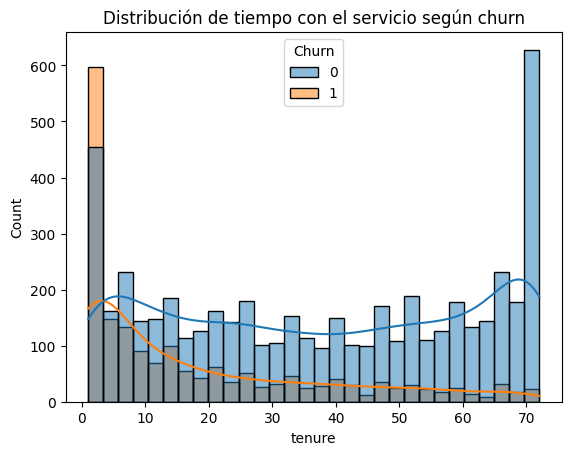

In [44]:
sns.histplot(
    data=df_clean,
    x='tenure',
    hue='Churn',
    bins=30,
    kde=True
)

plt.title('Distribución de tiempo con el servicio según churn')
plt.show()

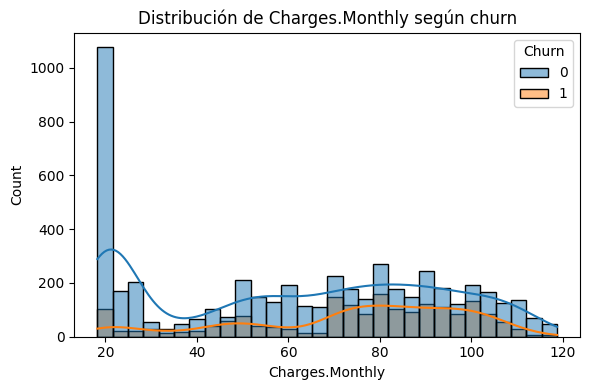

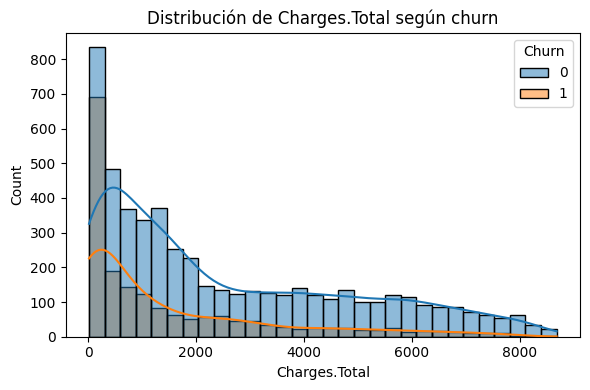

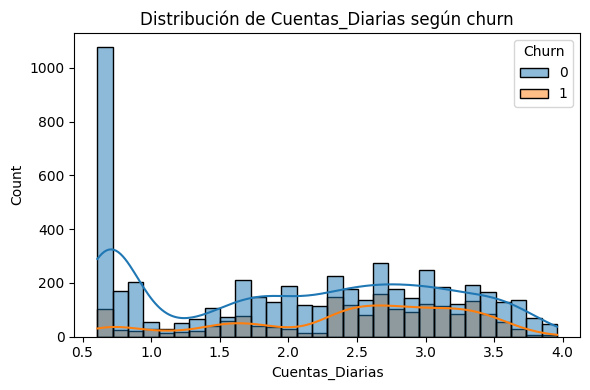

In [ ]:
num_cols = df_clean.select_dtypes(include=['float64']).columns

for col in num_cols:

    plt.figure(figsize=(6,4))

    sns.histplot(
        data=df_clean,
        x=col,
        hue='Churn',
        bins=30,
        kde=True
    )

    plt.title(f'Distribución de {col} según la evasión')

    plt.tight_layout()
    plt.show()

### Informe Final

Primero nos enfocamos en el conteo de evasión por variables categóricas. Aquí notamos que destacan algunos casos en los cuales se presenta muy frecuentemente la evasión de clientes: 
- Los ciudadanos mayores no son quienes presentan una mayor evasión, que puede explicarse desde el punto de vista de que es una población baja dentro del conjunto de datos.
- Los solteros tienden a presentar una mayor evasión, quiza pueda explicarse desde el punto de vista de la estabilidad financiera o incluso del modo de vida.
- La mayoria de los que presentan evasión no son dependientes.
- Curiosamente la mayoria de clientes que se retiran tenían contratado el servicio telefónico, pero puede deberse a que en realidad la mayoria de la población tiene este servicio.
- Respecto al servicio de internet, la mayor parte de los evasores tenía fibra óptica, se sugiere hacer una revisión de la estabilidad de ese servicio en particular.
- La mayoria de quienes han salido no han recibido ni seguridad en línea, ni recuentos online, ni protección de dispositivos, ni soporte técnico. Se recomienda hacer una revisión del servicio al cliente para mitigar estas falencias.
- El contrato mes a mes domina en los casos de evasiones.
- La facturación sin papel está relacionada con más casos de evasión, se sugiere revisar si el cliente no está recibiendo respaldo de sus facturas e investigar la razón de esto.
- en la mayoría de los casos, el método de pago por checkeo electrónico está relacionado con la mayoria de los casos de evasión, se sugiere revisar qué problemas está presentando para dar solución y mitigar esta causa.

Enfocandonos ahora en el conteo de evasión por variables numéricas notamos lo siguiente:
- Las personas que llevan poco tiempo con el servicio tienden a retirarse más que quienes llevan mucho tiempo. Se recomienda buscar estrategias de fidelización de clientes nuevos.
- Las personas con más antigüedad en el servicio suelen retirarse un poco más debido a los cargos mensuales.
- la distribución de quienes se quedan y se van respecto a los cargos totales es aproximadamente la misma, de manera que no se puede considerar como un motivo de evasión importante.

## Juan José Pérez Avendaño